In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow Version: 2.21.0
All libraries imported successfully!


In [5]:
from pathlib import Path

# Dataset path
data_dir = Path("../data/PetImages")

cat_dir = data_dir / "Cat"
dog_dir = data_dir / "Dog"

print("Dataset path:", data_dir.resolve())
print("Cat folder exists:", cat_dir.exists())
print("Dog folder exists:", dog_dir.exists())

print("Total Cat images:", len(list(cat_dir.glob("*"))))
print("Total Dog images:", len(list(dog_dir.glob("*"))))

Dataset path: C:\Users\Admin\OneDrive\Documents\Cats-vs-Dogs-Classification\data\PetImages
Cat folder exists: True
Dog folder exists: True
Total Cat images: 12501
Total Dog images: 12501


In [6]:
from PIL import Image
from pathlib import Path

def remove_corrupted_images(folder_path):
    corrupted = 0
    
    for image_path in Path(folder_path).glob("*"):
        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            corrupted += 1
            image_path.unlink()
    
    return corrupted

corrupted_cats = remove_corrupted_images(cat_dir)
corrupted_dogs = remove_corrupted_images(dog_dir)

print("Corrupted Cat images removed:", corrupted_cats)
print("Corrupted Dog images removed:", corrupted_dogs)
print("Dataset cleaning completed!")

c:\Users\Admin\OneDrive\Documents\Cats-vs-Dogs-Classification\venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted Cat images removed: 2
Corrupted Dog images removed: 2
Dataset cleaning completed!


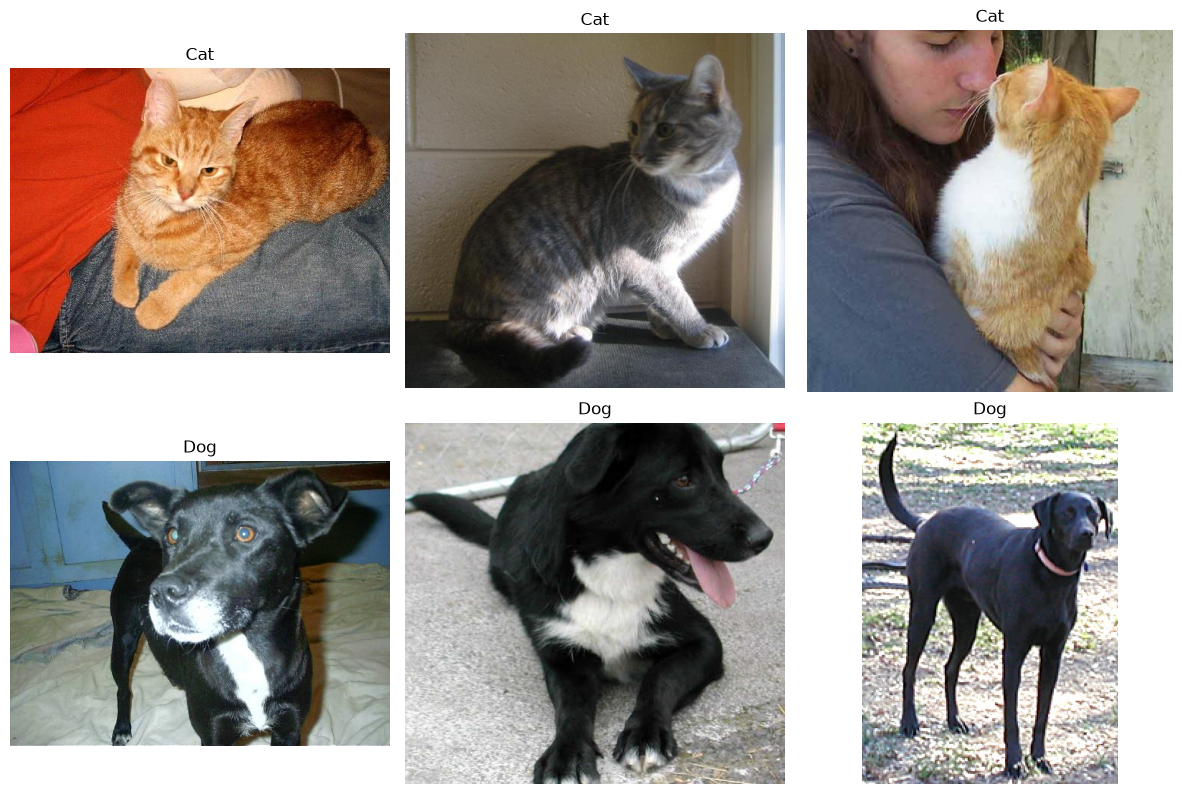

In [7]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Get random images
cat_images = list(cat_dir.glob("*"))
dog_images = list(dog_dir.glob("*"))

sample_images = random.sample(cat_images, 3) + random.sample(dog_images, 3)

plt.figure(figsize=(12, 8))

for i, image_path in enumerate(sample_images):
    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(image_path.parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
import random
from pathlib import Path

# Get all image paths
cat_images = list(cat_dir.glob("*"))
dog_images = list(dog_dir.glob("*"))

# Create dataset with labels
image_paths = []
labels = []

for img in cat_images:
    image_paths.append(str(img))
    labels.append(0)  # Cat = 0

for img in dog_images:
    image_paths.append(str(img))
    labels.append(1)  # Dog = 1

# Shuffle dataset
combined = list(zip(image_paths, labels))
random.seed(42)
random.shuffle(combined)

image_paths, labels = zip(*combined)

# Check total images
print("Total images:", len(image_paths))
print("Cats:", labels.count(0))
print("Dogs:", labels.count(1))

Total images: 24998
Cats: 12499
Dogs: 12499


In [9]:
from sklearn.model_selection import train_test_split

# First split: 70% Train and 30% Temporary
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Second split: 15% Validation and 15% Test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 17498
Validation images: 3750
Test images: 3750


In [10]:
IMG_SIZE = 128
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = image / 255.0
    return image, label


def create_dataset(paths, labels, training=False):
    paths = tf.constant(list(paths))
    labels = tf.constant(list(labels))

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=1000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


# Create datasets
train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels)
test_ds = create_dataset(test_paths, test_labels)

print("Train dataset created!")
print("Validation dataset created!")
print("Test dataset created!")

Train dataset created!
Validation dataset created!
Test dataset created!


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5


c:\Users\Admin\OneDrive\Documents\Cats-vs-Dogs-Classification\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


InvalidArgumentError: Graph execution error:

Detected at node DecodeJpeg defined at (most recent call last):
<stack traces unavailable>
Error in user-defined function passed to ParallelMapDatasetV2:1 transformation with iterator: Iterator::Root::Prefetch::BatchV2::Shuffle::ParallelMapV2: Trying to decode BMP format using a wrong op. Use `decode_bmp` or `decode_image` instead. Op used: DecodeJpeg
	 [[{{node DecodeJpeg}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_2252]

In [13]:
IMG_SIZE = 128
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

def create_dataset(paths, labels, training=False):
    paths = tf.constant(list(paths))
    labels = tf.constant(list(labels))

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=1000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels)
test_ds = create_dataset(test_paths, test_labels)

print("Datasets recreated successfully!")

Datasets recreated successfully!


In [14]:
EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5


InvalidArgumentError: Graph execution error:

Detected at node DecodeJpeg defined at (most recent call last):
<stack traces unavailable>
Error in user-defined function passed to ParallelMapDatasetV2:14 transformation with iterator: Iterator::Root::Prefetch::BatchV2::Shuffle::ParallelMapV2: Trying to decode BMP format using a wrong op. Use `decode_bmp` or `decode_image` instead. Op used: DecodeJpeg
	 [[{{node DecodeJpeg}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_2252]

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

from pathlib import Path
from sklearn.model_selection import train_test_split

In [2]:
data_dir = Path("../data/PetImages")

cat_dir = data_dir / "Cat"
dog_dir = data_dir / "Dog"

cat_images = list(cat_dir.glob("*"))
dog_images = list(dog_dir.glob("*"))

print("Cats:", len(cat_images))
print("Dogs:", len(dog_images))

Cats: 12499
Dogs: 12499


In [3]:
image_paths = []
labels = []

for img in cat_images:
    image_paths.append(str(img))
    labels.append(0)

for img in dog_images:
    image_paths.append(str(img))
    labels.append(1)

combined = list(zip(image_paths, labels))

random.seed(42)
random.shuffle(combined)

image_paths, labels = zip(*combined)

print("Total images:", len(image_paths))

Total images: 24998


In [4]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 17498
Validation: 3750
Test: 3750


In [5]:
IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)

    # Handles JPG, PNG, BMP automatically
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Set shape explicitly
    image.set_shape([None, None, 3])

    # Resize
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Normalize
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


def create_dataset(paths, labels, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (list(paths), list(labels))
    )

    ds = ds.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


# Create datasets
train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels)
test_ds = create_dataset(test_paths, test_labels)

print("Train dataset ready!")
print("Validation dataset ready!")
print("Test dataset ready!")

Train dataset ready!
Validation dataset ready!
Test dataset ready!


In [6]:
for images, labels_batch in train_ds.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels_batch.shape)
    print("Image data type:", images.dtype)
    print("Min value:", tf.reduce_min(images).numpy())
    print("Max value:", tf.reduce_max(images).numpy())

Images batch shape: (32, 128, 128, 3)
Labels batch shape: (32,)
Image data type: <dtype: 'float32'>
Min value: 0.0
Max value: 1.0


In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 3

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/3


c:\Users\Admin\OneDrive\Documents\Cats-vs-Dogs-Classification\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


547/547 ━━━━━━━━━━━━━━━━━━━━ 108s 191ms/step - accuracy: 0.5817 - loss: 0.6714 - val_accuracy: 0.6635 - val_loss: 0.6392
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 92s 167ms/step - accuracy: 0.6654 - loss: 0.6133 - val_accuracy: 0.6557 - val_loss: 0.6150
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 96s 174ms/step - accuracy: 0.7015 - loss: 0.5755 - val_accuracy: 0.7184 - val_loss: 0.5604


In [9]:
history_more = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 97s 175ms/step - accuracy: 0.7121 - loss: 0.5653 - val_accuracy: 0.7235 - val_loss: 0.5480
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 104s 189ms/step - accuracy: 0.7338 - loss: 0.5356 - val_accuracy: 0.7592 - val_loss: 0.5086
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 137s 248ms/step - accuracy: 0.7567 - loss: 0.5118 - val_accuracy: 0.7723 - val_loss: 0.4912
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 99s 181ms/step - accuracy: 0.7670 - loss: 0.4929 - val_accuracy: 0.7779 - val_loss: 0.4782
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 136s 247ms/step - accuracy: 0.7839 - loss: 0.4680 - val_accuracy: 0.7904 - val_loss: 0.4519


In [10]:
model.save("../models/cats_vs_dogs_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
print("TensorFlow:", tf.__version__)
print("Model:", model)

In [ ]:
print("Kernel is working!")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("../models/cats_vs_dogs_model.keras")

print("Model loaded successfully!")

In [1]:
print("HELLO")

HELLO


In [2]:
from tensorflow.keras.models import load_model

model = load_model("../models/cats_vs_dogs_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

NameError: name 'test_ds' is not defined

In [4]:
from pathlib import Path
import random
from sklearn.model_selection import train_test_split

data_dir = Path("../data/PetImages")
cat_dir = data_dir / "Cat"
dog_dir = data_dir / "Dog"

cat_files = list(cat_dir.glob("*"))
dog_files = list(dog_dir.glob("*"))

files = cat_files + dog_files
labels = [0] * len(cat_files) + [1] * len(dog_files)

train_files, temp_files, train_labels, temp_labels = train_test_split(
    files, labels, test_size=0.30, stratify=labels, random_state=42
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Train: 17498
Validation: 3750
Test: 3750


In [5]:
from pathlib import Path
from sklearn.model_selection import train_test_split

data_dir = Path("../data/PetImages")
cat_dir = data_dir / "Cat"
dog_dir = data_dir / "Dog"

cat_files = list(cat_dir.glob("*"))
dog_files = list(dog_dir.glob("*"))

files = cat_files + dog_files
labels = [0] * len(cat_files) + [1] * len(dog_files)

train_files, temp_files, train_labels, temp_labels = train_test_split(
    files, labels, test_size=0.30, stratify=labels, random_state=42
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Train: 17498
Validation: 3750
Test: 3750


In [6]:
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def create_dataset(file_paths, labels, shuffle=False):
    paths = [str(p) for p in file_paths]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds = create_dataset(test_files, test_labels)

print("Test dataset created successfully!")

Test dataset created successfully!


In [7]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

 31/118 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8135 - loss: 0.4375

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_660]

In [9]:
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)

    # Decode all supported image formats
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [10]:
test_ds = create_dataset(test_files, test_labels)

print("Test dataset recreated successfully!")

Test dataset recreated successfully!


In [11]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

 31/118 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8135 - loss: 0.4375

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_660]

In [12]:
def create_safe_dataset(file_paths, labels, shuffle=False):
    paths = [str(p) for p in file_paths]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def safe_load(path, label):
        try:
            image = tf.io.read_file(path)
            image = tf.io.decode_image(
                image,
                channels=3,
                expand_animations=False
            )
            image.set_shape([None, None, 3])
            image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
            image = tf.cast(image, tf.float32) / 255.0
            return image, label
        except:
            return tf.zeros([IMG_SIZE, IMG_SIZE, 3]), label

    ds = ds.map(safe_load, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds = create_safe_dataset(test_files, test_labels)

print("Safe test dataset created!")

Safe test dataset created!


In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

 31/118 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8135 - loss: 0.4375

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_660]

In [14]:
from PIL import Image

bad_files = []

for file_path in test_files:
    try:
        with Image.open(file_path) as img:
            img.verify()
        with Image.open(file_path) as img:
            if img.mode not in ["RGB", "L", "RGBA"]:
                bad_files.append((file_path, img.mode))
    except Exception as e:
        bad_files.append((file_path, "CORRUPTED"))

print("Problematic test images:", len(bad_files))

for item in bad_files:
    print(item)

Problematic test images: 6
(WindowsPath('../data/PetImages/Cat/9171.jpg'), 'P')
(WindowsPath('../data/PetImages/Dog/10158.jpg'), 'P')
(WindowsPath('../data/PetImages/Cat/936.jpg'), 'P')
(WindowsPath('../data/PetImages/Cat/7978.jpg'), 'P')
(WindowsPath('../data/PetImages/Cat/5370.jpg'), 'P')
(WindowsPath('../data/PetImages/Dog/1789.jpg'), 'CMYK')


In [15]:
bad_paths = {str(item[0]) for item in bad_files}

clean_test_files = [
    path for path in test_files
    if str(path) not in bad_paths
]

clean_test_labels = [
    label for path, label in zip(test_files, test_labels)
    if str(path) not in bad_paths
]

print("Original test images:", len(test_files))
print("Problematic images removed:", len(test_files) - len(clean_test_files))
print("Clean test images:", len(clean_test_files))

test_ds = create_dataset(clean_test_files, clean_test_labels)

print("Clean test dataset created!")

Original test images: 3750
Problematic images removed: 6
Clean test images: 3744
Clean test dataset created!


In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

 30/117 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8104 - loss: 0.4389

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_660]

In [17]:
from PIL import Image
import numpy as np
import tensorflow as tf

def load_image_pil(path, label):
    def load_image(path_bytes):
        path = path_bytes.decode("utf-8")
        with Image.open(path) as img:
            img = img.convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            return np.array(img, dtype=np.float32) / 255.0

    image = tf.numpy_function(
        load_image_pil_wrapper,
        [path],
        tf.float32
    )
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return image, label

def load_pil(path, label):
    image = tf.numpy_function(
        lambda p: np.array(
            Image.open(p.decode("utf-8")).convert("RGB").resize(
                (IMG_SIZE, IMG_SIZE)
            ),
            dtype=np.float32
        ) / 255.0,
        [path],
        tf.float32
    )
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return image, label

test_paths = [str(p) for p in clean_test_files]

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, clean_test_labels)
)

test_ds = test_ds.map(
    load_pil,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("PIL-based test dataset ready!")

PIL-based test dataset ready!


In [18]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8061 - loss: 0.4357
Test Loss: 0.4356977045536041
Test Accuracy: 0.8060897588729858
Test Accuracy (%): 80.60897588729858


117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step


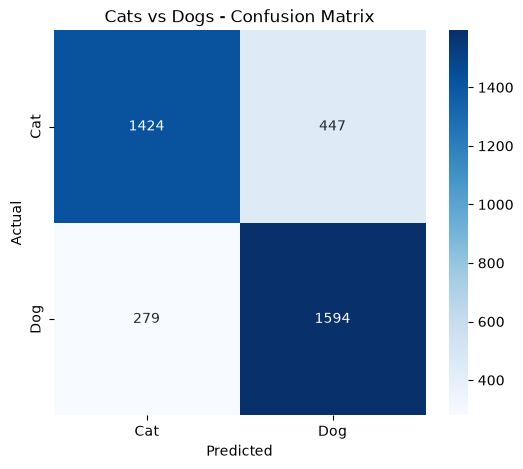

              precision    recall  f1-score   support

         Cat       0.84      0.76      0.80      1871
         Dog       0.78      0.85      0.81      1873

    accuracy                           0.81      3744
   macro avg       0.81      0.81      0.81      3744
weighted avg       0.81      0.81      0.81      3744



In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_true = np.array(clean_test_labels)

y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cats vs Dogs - Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

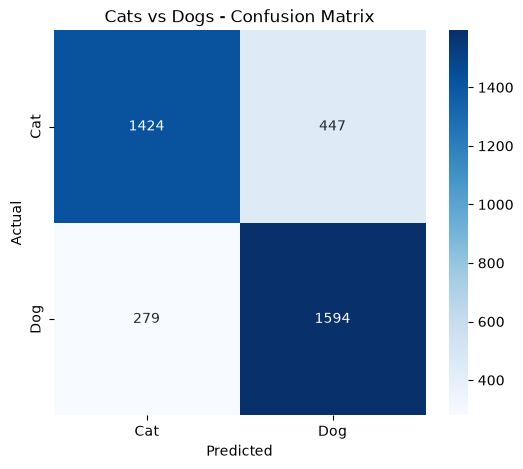

Confusion matrix saved successfully!


In [21]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cats vs Dogs - Confusion Matrix")

plt.savefig("../outputs/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved successfully!")

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

# Select 5 cats + 5 dogs
cat_samples = [(p, l) for p, l in zip(clean_test_files, clean_test_labels) if l == 0][:5]
dog_samples = [(p, l) for p, l in zip(clean_test_files, clean_test_labels) if l == 1][:5]

samples = cat_samples + dog_samples

for i, (file_path, true_label) in enumerate(samples, start=1):

    # Load image and convert to RGB
    img = Image.open(file_path).convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))

    # Prepare image for model
    img_array = np.array(img_resized, dtype=np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    probability = model.predict(img_array, verbose=0)[0][0]
    predicted_label = 1 if probability >= 0.5 else 0

    actual_name = "Dog" if true_label == 1 else "Cat"
    predicted_name = "Dog" if predicted_label == 1 else "Cat"

    # Save image with labels
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Actual: {actual_name} | Predicted: {predicted_name}\n"
        f"Confidence: {probability if predicted_label == 1 else 1-probability:.2%}"
    )

    save_path = output_dir / f"sample_inference_{i:02d}.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

    print(f"Saved: {save_path}")

print("\n✅ 10 sample inference images saved successfully!")

Saved: ..\outputs\sample_inference_01.png
Saved: ..\outputs\sample_inference_02.png
Saved: ..\outputs\sample_inference_03.png
Saved: ..\outputs\sample_inference_04.png
Saved: ..\outputs\sample_inference_05.png
Saved: ..\outputs\sample_inference_06.png
Saved: ..\outputs\sample_inference_07.png
Saved: ..\outputs\sample_inference_08.png
Saved: ..\outputs\sample_inference_09.png
Saved: ..\outputs\sample_inference_10.png

✅ 10 sample inference images saved successfully!
